In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/neurogolf-2026/task221.json
/kaggle/input/competitions/neurogolf-2026/task189.json
/kaggle/input/competitions/neurogolf-2026/task292.json
/kaggle/input/competitions/neurogolf-2026/task176.json
/kaggle/input/competitions/neurogolf-2026/task210.json
/kaggle/input/competitions/neurogolf-2026/task363.json
/kaggle/input/competitions/neurogolf-2026/task179.json
/kaggle/input/competitions/neurogolf-2026/task154.json
/kaggle/input/competitions/neurogolf-2026/task357.json
/kaggle/input/competitions/neurogolf-2026/task304.json
/kaggle/input/competitions/neurogolf-2026/task022.json
/kaggle/input/competitions/neurogolf-2026/task090.json
/kaggle/input/competitions/neurogolf-2026/task115.json
/kaggle/input/competitions/neurogolf-2026/task076.json
/kaggle/input/competitions/neurogolf-2026/task329.json
/kaggle/input/competitions/neurogolf-2026/task224.json
/kaggle/input/competitions/neurogolf-2026/task166.json
/kaggle/input/competitions/neurogolf-2026/task169.json
/kaggle/in

In [2]:
# Kaggle notebook: attach the competition data to the notebook
import kagglehub
from pathlib import Path
import zipfile

# This attaches the NeuroGolf competition files to the notebook
path = kagglehub.competition_download("neurogolf-2026")
print("Competition files path:", path)

# Optional: inspect what was made available
p = Path(path)
for item in sorted(p.iterdir())[:10]:
    print(item)

Competition files path: /kaggle/input/competitions/neurogolf-2026
/kaggle/input/competitions/neurogolf-2026/neurogolf_utils
/kaggle/input/competitions/neurogolf-2026/task001.json
/kaggle/input/competitions/neurogolf-2026/task002.json
/kaggle/input/competitions/neurogolf-2026/task003.json
/kaggle/input/competitions/neurogolf-2026/task004.json
/kaggle/input/competitions/neurogolf-2026/task005.json
/kaggle/input/competitions/neurogolf-2026/task006.json
/kaggle/input/competitions/neurogolf-2026/task007.json
/kaggle/input/competitions/neurogolf-2026/task008.json
/kaggle/input/competitions/neurogolf-2026/task009.json


In [3]:
# =============================
# STEP 1: Import libraries
# =============================
from pathlib import Path
import json
import numpy as np


# =============================
# STEP 2: Point to correct competition folder
# =============================
# Kaggle competitions are stored under /kaggle/input/competitions/
data_dir = Path("/kaggle/input/competitions/neurogolf-2026")


# =============================
# STEP 3: Check contents of this folder
# =============================
print("Contents of competition folder:\n")

for path in data_dir.iterdir():
    print(path)


# =============================
# STEP 4: Search for JSON files
# =============================
# rglob searches recursively through all subfolders
json_files = sorted(data_dir.rglob("*.json"))

print("\nNumber of JSON files found:", len(json_files))

print("\nFirst 10 JSON files:")
for f in json_files[:10]:
    print(f)


# =============================
# STEP 5: Load first 3 tasks
# =============================
tasks = []

for file in json_files[:3]:
    with open(file, "r") as f:
        task = json.load(f)
        tasks.append((file.name, task))

print("\nLoaded", len(tasks), "tasks")


# =============================
# STEP 6: Inspect tasks
# =============================
for name, task in tasks:
    print(f"\n=== {name} ===")
    print("Keys:", task.keys())
    print("Train examples:", len(task["train"]))
    print("Test examples:", len(task["test"]))

    # Show shapes
    for i, ex in enumerate(task["train"]):
        inp = np.array(ex["input"], dtype=int)
        out = np.array(ex["output"], dtype=int)
        print(f"Train {i+1}: {inp.shape} -> {out.shape}")


# =============================
# STEP 7: View first example clearly
# =============================
name, task = tasks[0]

example = task["train"][0]

inp = np.array(example["input"], dtype=int)
out = np.array(example["output"], dtype=int)

print(f"\n=== First task: {name} ===")

print("\nInput grid:")
print(inp)

print("\nOutput grid:")
print(out)

Contents of competition folder:

/kaggle/input/competitions/neurogolf-2026/task221.json
/kaggle/input/competitions/neurogolf-2026/task189.json
/kaggle/input/competitions/neurogolf-2026/task292.json
/kaggle/input/competitions/neurogolf-2026/task176.json
/kaggle/input/competitions/neurogolf-2026/task210.json
/kaggle/input/competitions/neurogolf-2026/task363.json
/kaggle/input/competitions/neurogolf-2026/task179.json
/kaggle/input/competitions/neurogolf-2026/task154.json
/kaggle/input/competitions/neurogolf-2026/task357.json
/kaggle/input/competitions/neurogolf-2026/task304.json
/kaggle/input/competitions/neurogolf-2026/task022.json
/kaggle/input/competitions/neurogolf-2026/task090.json
/kaggle/input/competitions/neurogolf-2026/task115.json
/kaggle/input/competitions/neurogolf-2026/task076.json
/kaggle/input/competitions/neurogolf-2026/task329.json
/kaggle/input/competitions/neurogolf-2026/task224.json
/kaggle/input/competitions/neurogolf-2026/task166.json
/kaggle/input/competitions/neuro

In [4]:
# =============================
# STEP 1: Import Path
# =============================
# Path helps us inspect folders in the Kaggle environment
from pathlib import Path


# =============================
# STEP 2: Look at everything inside /kaggle/input
# =============================
# This is the most important check.
# It shows the actual dataset folder names Kaggle attached to your notebook.
input_root = Path("/kaggle/input")

print("Top-level folders inside /kaggle/input:\n")

for path in input_root.iterdir():
    print(path)

Top-level folders inside /kaggle/input:

/kaggle/input/competitions


In [5]:

# =============================
# STEP 3: Look inside /kaggle/input/competitions
# =============================
# We now inspect the competitions folder to see which competition data
# is attached to the notebook.
from pathlib import Path

competitions_dir = Path("/kaggle/input/competitions")

print("Contents of /kaggle/input/competitions:\n")

for path in competitions_dir.iterdir():
    print(path)

Contents of /kaggle/input/competitions:

/kaggle/input/competitions/neurogolf-2026


In [6]:
# =============================
# STEP 4: Look inside the NeuroGolf competition folder
# =============================
# Replace the folder name below if Kaggle shows a slightly different one.
data_dir = Path("/kaggle/input/competitions/neurogolf-2026")

print("Contents of the NeuroGolf folder:\n")

for path in data_dir.rglob("*"):
    print(path)

Contents of the NeuroGolf folder:

/kaggle/input/competitions/neurogolf-2026/task221.json
/kaggle/input/competitions/neurogolf-2026/task189.json
/kaggle/input/competitions/neurogolf-2026/task292.json
/kaggle/input/competitions/neurogolf-2026/task176.json
/kaggle/input/competitions/neurogolf-2026/task210.json
/kaggle/input/competitions/neurogolf-2026/task363.json
/kaggle/input/competitions/neurogolf-2026/task179.json
/kaggle/input/competitions/neurogolf-2026/task154.json
/kaggle/input/competitions/neurogolf-2026/task357.json
/kaggle/input/competitions/neurogolf-2026/task304.json
/kaggle/input/competitions/neurogolf-2026/task022.json
/kaggle/input/competitions/neurogolf-2026/task090.json
/kaggle/input/competitions/neurogolf-2026/task115.json
/kaggle/input/competitions/neurogolf-2026/task076.json
/kaggle/input/competitions/neurogolf-2026/task329.json
/kaggle/input/competitions/neurogolf-2026/task224.json
/kaggle/input/competitions/neurogolf-2026/task166.json
/kaggle/input/competitions/neu

In [7]:
# =============================
# STEP 5A: Find JSON task files directly
# =============================
json_files = sorted(data_dir.rglob("*.json"))

print("Number of JSON files found:", len(json_files))
print("\nFirst 10 JSON files:")

for f in json_files[:10]:
    print(f)

Number of JSON files found: 400

First 10 JSON files:
/kaggle/input/competitions/neurogolf-2026/task001.json
/kaggle/input/competitions/neurogolf-2026/task002.json
/kaggle/input/competitions/neurogolf-2026/task003.json
/kaggle/input/competitions/neurogolf-2026/task004.json
/kaggle/input/competitions/neurogolf-2026/task005.json
/kaggle/input/competitions/neurogolf-2026/task006.json
/kaggle/input/competitions/neurogolf-2026/task007.json
/kaggle/input/competitions/neurogolf-2026/task008.json
/kaggle/input/competitions/neurogolf-2026/task009.json
/kaggle/input/competitions/neurogolf-2026/task010.json


In [8]:
# =============================
# LIST FILES INSIDE COMPETITION FOLDER
# =============================
from pathlib import Path

data_dir = Path("/kaggle/input/competitions/neurogolf-2026")

print("Files inside competition folder:\n")

for p in data_dir.iterdir():
    print(p)

Files inside competition folder:

/kaggle/input/competitions/neurogolf-2026/task221.json
/kaggle/input/competitions/neurogolf-2026/task189.json
/kaggle/input/competitions/neurogolf-2026/task292.json
/kaggle/input/competitions/neurogolf-2026/task176.json
/kaggle/input/competitions/neurogolf-2026/task210.json
/kaggle/input/competitions/neurogolf-2026/task363.json
/kaggle/input/competitions/neurogolf-2026/task179.json
/kaggle/input/competitions/neurogolf-2026/task154.json
/kaggle/input/competitions/neurogolf-2026/task357.json
/kaggle/input/competitions/neurogolf-2026/task304.json
/kaggle/input/competitions/neurogolf-2026/task022.json
/kaggle/input/competitions/neurogolf-2026/task090.json
/kaggle/input/competitions/neurogolf-2026/task115.json
/kaggle/input/competitions/neurogolf-2026/task076.json
/kaggle/input/competitions/neurogolf-2026/task329.json
/kaggle/input/competitions/neurogolf-2026/task224.json
/kaggle/input/competitions/neurogolf-2026/task166.json
/kaggle/input/competitions/neur

In [9]:
# =============================
# LOAD FIRST 3 TASK FILES
# =============================
import json
import numpy as np

# Get all JSON files
json_files = sorted(data_dir.glob("*.json"))

print("Total tasks:", len(json_files))

# Load first 3 tasks
tasks = []

for file in json_files[:3]:
    with open(file, "r") as f:
        task = json.load(f)
        tasks.append((file.name, task))

print("Loaded", len(tasks), "tasks")

Total tasks: 400
Loaded 3 tasks


In [10]:
# =============================
# INSPECT TASK STRUCTURE
# =============================
for name, task in tasks:
    print(f"\n=== {name} ===")
    print("Keys:", task.keys())
    print("Train examples:", len(task["train"]))
    print("Test examples:", len(task["test"]))


=== task001.json ===
Keys: dict_keys(['train', 'test', 'arc-gen'])
Train examples: 5
Test examples: 1

=== task002.json ===
Keys: dict_keys(['train', 'test', 'arc-gen'])
Train examples: 5
Test examples: 1

=== task003.json ===
Keys: dict_keys(['train', 'test', 'arc-gen'])
Train examples: 3
Test examples: 1


In [11]:
# =============================
# CHECK INPUT/OUTPUT SHAPES
# =============================
for name, task in tasks:
    print(f"\n=== {name} ===")
    
    for i, ex in enumerate(task["train"]):
        inp = np.array(ex["input"])
        out = np.array(ex["output"])
        
        print(f"Train {i+1}: {inp.shape} -> {out.shape}")


=== task001.json ===
Train 1: (3, 3) -> (9, 9)
Train 2: (3, 3) -> (9, 9)
Train 3: (3, 3) -> (9, 9)
Train 4: (3, 3) -> (9, 9)
Train 5: (3, 3) -> (9, 9)

=== task002.json ===
Train 1: (6, 6) -> (6, 6)
Train 2: (10, 10) -> (10, 10)
Train 3: (10, 10) -> (10, 10)
Train 4: (10, 10) -> (10, 10)
Train 5: (20, 20) -> (20, 20)

=== task003.json ===
Train 1: (6, 3) -> (9, 3)
Train 2: (6, 3) -> (9, 3)
Train 3: (6, 3) -> (9, 3)


In [12]:
# =============================
# VISUALIZATION SETUP
# =============================
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# ARC color palette
arc_colors = [
    "#000000", "#0074D9", "#FF4136", "#2ECC40", "#FFDC00",
    "#AAAAAA", "#F012BE", "#FF851B", "#7FDBFF", "#870C25"
]

cmap = ListedColormap(arc_colors)
norm = BoundaryNorm(range(11), cmap.N)


# Function to display input vs output
def show_example(inp, out, title=""):
    fig, axes = plt.subplots(1, 2, figsize=(6, 3))

    axes[0].imshow(inp, cmap=cmap, norm=norm)
    axes[0].set_title("Input")
    axes[0].axis("off")

    axes[1].imshow(out, cmap=cmap, norm=norm)
    axes[1].set_title("Output")
    axes[1].axis("off")

    if title:
        fig.suptitle(title)

    plt.tight_layout()
    plt.show()

Task: task001.json


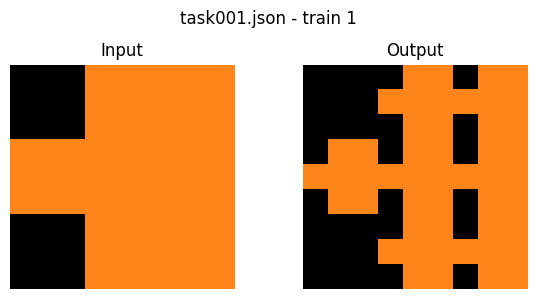

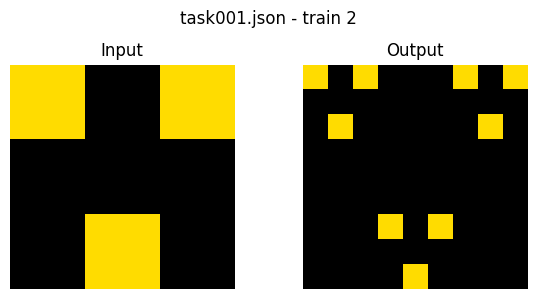

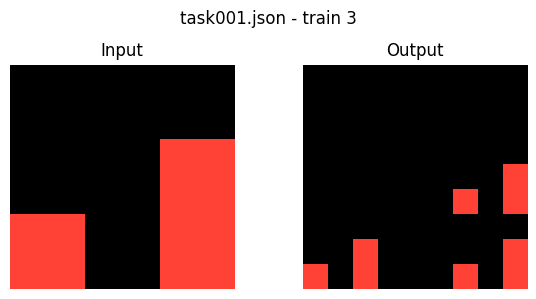

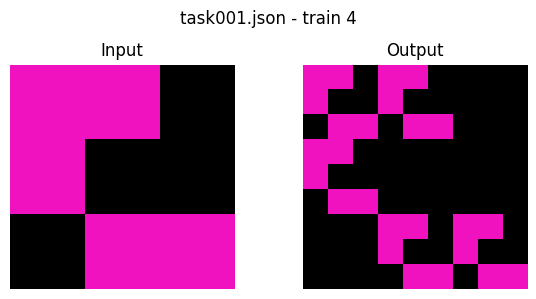

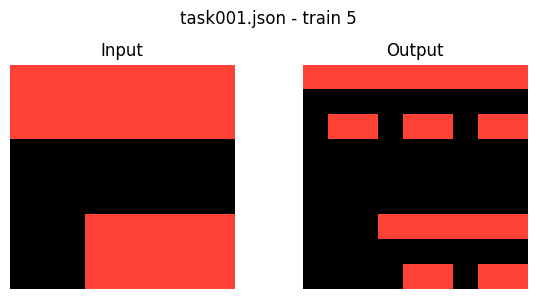

In [13]:
# =============================
# SHOW FIRST TASK
# =============================
name, task = tasks[0]

print("Task:", name)

for i, ex in enumerate(task["train"]):
    inp = np.array(ex["input"])
    out = np.array(ex["output"])
    
    show_example(inp, out, title=f"{name} - train {i+1}")

In [14]:
# =============================
# TEST: Keep every 2nd pixel pattern
# =============================
def checker_mask(grid):
    h, w = grid.shape
    out = np.zeros_like(grid)

    for r in range(h):
        for c in range(w):
            # Example pattern: keep alternating positions
            if (r + c) % 2 == 0:
                out[r, c] = grid[r, c]

    return out

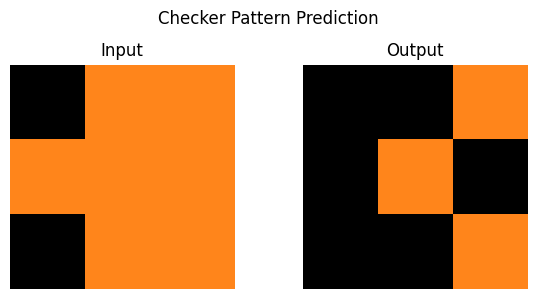

Matches actual output? False


In [15]:
inp = np.array(task["train"][0]["input"])
out = np.array(task["train"][0]["output"])

pred = checker_mask(inp)

show_example(inp, pred, title="Checker Pattern Prediction")

print("Matches actual output?", np.array_equal(pred, out))

In [16]:
# Show all training pairs for task 1 as arrays
name, task = tasks[0]

for i, ex in enumerate(task["train"]):
    inp = np.array(ex["input"], dtype=int)
    out = np.array(ex["output"], dtype=int)

    print(f"\n--- Train {i+1} ---")
    print("Input shape :", inp.shape)
    print(inp)
    print("\nOutput shape:", out.shape)
    print(out)


--- Train 1 ---
Input shape : (3, 3)
[[0 7 7]
 [7 7 7]
 [0 7 7]]

Output shape: (9, 9)
[[0 0 0 0 7 7 0 7 7]
 [0 0 0 7 7 7 7 7 7]
 [0 0 0 0 7 7 0 7 7]
 [0 7 7 0 7 7 0 7 7]
 [7 7 7 7 7 7 7 7 7]
 [0 7 7 0 7 7 0 7 7]
 [0 0 0 0 7 7 0 7 7]
 [0 0 0 7 7 7 7 7 7]
 [0 0 0 0 7 7 0 7 7]]

--- Train 2 ---
Input shape : (3, 3)
[[4 0 4]
 [0 0 0]
 [0 4 0]]

Output shape: (9, 9)
[[4 0 4 0 0 0 4 0 4]
 [0 0 0 0 0 0 0 0 0]
 [0 4 0 0 0 0 0 4 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 4 0 4 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 4 0 0 0 0]]

--- Train 3 ---
Input shape : (3, 3)
[[0 0 0]
 [0 0 2]
 [2 0 2]]

Output shape: (9, 9)
[[0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 2]
 [0 0 0 0 0 0 2 0 2]
 [0 0 0 0 0 0 0 0 0]
 [0 0 2 0 0 0 0 0 2]
 [2 0 2 0 0 0 2 0 2]]

--- Train 4 ---
Input shape : (3, 3)
[[6 6 0]
 [6 0 0]
 [0 6 6]]

Output shape: (9, 9)
[[6 6 0 6 6 0 0 0 0]
 [6 0 0 6 0 0 0 0 0]
 [0 6 6 0 6 6 0 0 0]
 [6 6 0 0 0 0 0

In [17]:
for i, ex in enumerate(task["train"]):
    inp = np.array(ex["input"], dtype=int)
    out = np.array(ex["output"], dtype=int)
    print(f"Train {i+1}: {inp.shape} -> {out.shape}")

Train 1: (3, 3) -> (9, 9)
Train 2: (3, 3) -> (9, 9)
Train 3: (3, 3) -> (9, 9)
Train 4: (3, 3) -> (9, 9)
Train 5: (3, 3) -> (9, 9)


In [18]:
for i, ex in enumerate(task["train"]):
    inp = np.array(ex["input"], dtype=int)
    out = np.array(ex["output"], dtype=int)

    print(f"\nTrain {i+1}")
    print("Input colors :", sorted(np.unique(inp).tolist()))
    print("Output colors:", sorted(np.unique(out).tolist()))


Train 1
Input colors : [0, 7]
Output colors: [0, 7]

Train 2
Input colors : [0, 4]
Output colors: [0, 4]

Train 3
Input colors : [0, 2]
Output colors: [0, 2]

Train 4
Input colors : [0, 6]
Output colors: [0, 6]

Train 5
Input colors : [0, 2]
Output colors: [0, 2]


Hypothesis A: keep only every other row/column inside the colored area

In [19]:
def sample_every_other(grid):
    out = np.zeros_like(grid)
    out[::2, ::2] = grid[::2, ::2]
    return out

Hypothesis B: vertical stripe sampling

In [20]:
def vertical_stripes(grid):
    out = np.zeros_like(grid)
    out[:, ::2] = grid[:, ::2]
    return out

Hypothesis C: horizontal stripe sampling

In [21]:
def horizontal_stripes(grid):
    out = np.zeros_like(grid)
    out[::2, :] = grid[::2, :]
    return out

Hypothesis D: checker masking

In [22]:
def checker_mask(grid):
    out = np.zeros_like(grid)
    h, w = grid.shape
    for r in range(h):
        for c in range(w):
            if (r + c) % 2 == 0:
                out[r, c] = grid[r, c]
    return out

In [23]:
# =============================
# DEFINE ALL TEST FUNCTIONS
# =============================

# This function keeps only every 2nd row and every 2nd column
# All other positions are set to 0 (black)
def sample_every_other(grid):
    # Create an output grid filled with zeros (same shape as input)
    out = np.zeros_like(grid)
    
    # Copy values from input at positions:
    # row 0,2,4,... and column 0,2,4,...
    out[::2, ::2] = grid[::2, ::2]
    
    # Return the filtered grid
    return out


# This function keeps vertical stripes (every 2nd column)
def vertical_stripes(grid):
    # Create an empty grid (all zeros)
    out = np.zeros_like(grid)
    
    # Copy all rows, but only columns 0,2,4,...
    out[:, ::2] = grid[:, ::2]
    
    # Return the result
    return out


# This function keeps horizontal stripes (every 2nd row)
def horizontal_stripes(grid):
    # Create an empty grid (all zeros)
    out = np.zeros_like(grid)
    
    # Copy all columns, but only rows 0,2,4,...
    out[::2, :] = grid[::2, :]
    
    # Return the result
    return out


# This function applies a checkerboard pattern
# It keeps cells where (row + column) is even
def checker_mask(grid):
    # Create an empty grid (all zeros)
    out = np.zeros_like(grid)
    
    # Get grid height and width
    h, w = grid.shape
    
    # Loop through every cell in the grid
    for r in range(h):
        for c in range(w):
            
            # If the position follows checker pattern
            if (r + c) % 2 == 0:
                
                # Keep the original value
                out[r, c] = grid[r, c]
    
    # Return the result
    return out

sample_every_other False


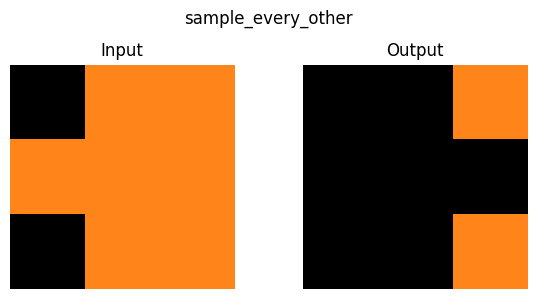

vertical_stripes False


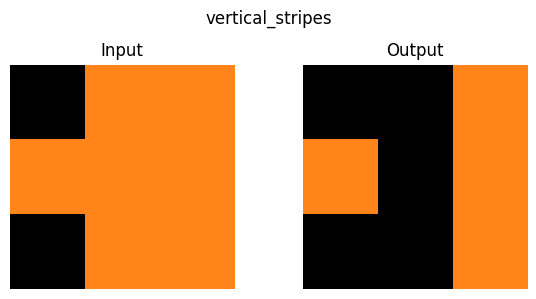

horizontal_stripes False


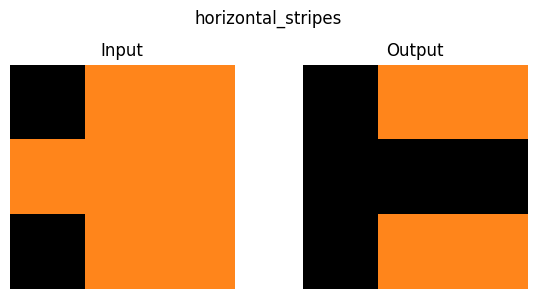

checker_mask False


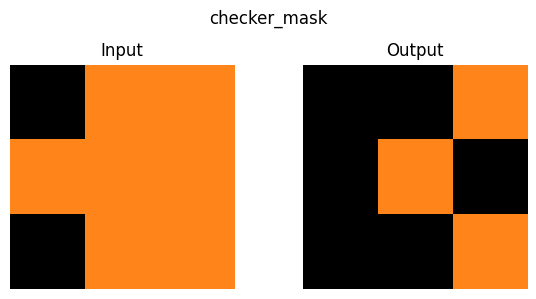

In [24]:
# =============================
# TEST DIFFERENT RULE HYPOTHESES
# =============================

# Select the first training example from the task
ex = task["train"][0]

# Convert input and output to numpy arrays
inp = np.array(ex["input"], dtype=int)
out = np.array(ex["output"], dtype=int)


# Store predictions from each rule
candidates = {
    "sample_every_other": sample_every_other(inp),   # Test sparse sampling
    "vertical_stripes": vertical_stripes(inp),       # Test vertical stripe rule
    "horizontal_stripes": horizontal_stripes(inp),   # Test horizontal stripe rule
    "checker_mask": checker_mask(inp),               # Test checkerboard rule
}


# Loop through each rule and compare with actual output
for name, pred in candidates.items():
    
    # Print whether the prediction matches the true output
    print(name, np.array_equal(pred, out))
    
    # Visualize the prediction side-by-side with input
    show_example(inp, pred, title=name)

In [25]:
# Print the first training example exactly
ex = task["train"][0]

inp = np.array(ex["input"], dtype=int)
out = np.array(ex["output"], dtype=int)

print("INPUT")
print(inp)

print("\nOUTPUT")
print(out)

print("\nInput shape:", inp.shape)
print("Output shape:", out.shape)

print("\nInput colors:", sorted(np.unique(inp).tolist()))
print("Output colors:", sorted(np.unique(out).tolist()))

INPUT
[[0 7 7]
 [7 7 7]
 [0 7 7]]

OUTPUT
[[0 0 0 0 7 7 0 7 7]
 [0 0 0 7 7 7 7 7 7]
 [0 0 0 0 7 7 0 7 7]
 [0 7 7 0 7 7 0 7 7]
 [7 7 7 7 7 7 7 7 7]
 [0 7 7 0 7 7 0 7 7]
 [0 0 0 0 7 7 0 7 7]
 [0 0 0 7 7 7 7 7 7]
 [0 0 0 0 7 7 0 7 7]]

Input shape: (3, 3)
Output shape: (9, 9)

Input colors: [0, 7]
Output colors: [0, 7]


In [26]:
# =============================
# STEP 1: Load the first train example from task 1
# =============================
# We convert the input and output to NumPy arrays
# so we can compare candidate transformation rules.
ex = task["train"][0]

inp = np.array(ex["input"], dtype=int)
out = np.array(ex["output"], dtype=int)

print("INPUT SHAPE :", inp.shape)
print("OUTPUT SHAPE:", out.shape)

print("\nINPUT")
print(inp)

print("\nOUTPUT")
print(out)

INPUT SHAPE : (3, 3)
OUTPUT SHAPE: (9, 9)

INPUT
[[0 7 7]
 [7 7 7]
 [0 7 7]]

OUTPUT
[[0 0 0 0 7 7 0 7 7]
 [0 0 0 7 7 7 7 7 7]
 [0 0 0 0 7 7 0 7 7]
 [0 7 7 0 7 7 0 7 7]
 [7 7 7 7 7 7 7 7 7]
 [0 7 7 0 7 7 0 7 7]
 [0 0 0 0 7 7 0 7 7]
 [0 0 0 7 7 7 7 7 7]
 [0 0 0 0 7 7 0 7 7]]


In [27]:
# =============================
# STEP 2: Define expansion rule candidates
# =============================

# Rule A:
# Replace each input cell with a k x k block of the same value.
# This is ordinary nearest-neighbor scaling.
def kron_scale(grid, k):
    return np.kron(grid, np.ones((k, k), dtype=int))


# Rule B:
# Repeat the whole input grid across rows and columns.
# Example: a 3x3 grid repeated 3 times by 3 times becomes 9x9.
def tile_repeat(grid, rep_r, rep_c):
    return np.tile(grid, (rep_r, rep_c))


# Rule C:
# Use the input as a mask.
# For every nonzero cell in the input, place a full copy of the input
# into the matching block of the output.
# If the input cell is zero, leave that block black.
def block_stamp_expand(grid):
    h, w = grid.shape

    # Output is made of h x w blocks, each block having shape h x w
    out = np.zeros((h * h, w * w), dtype=int)

    # Loop through each cell of the input
    for r in range(h):
        for c in range(w):
            # If the input cell is not black, stamp the full input
            # into the corresponding block of the output
            if grid[r, c] != 0:
                out[r*h:(r+1)*h, c*w:(c+1)*w] = grid

    return out

kron_scale_3 False


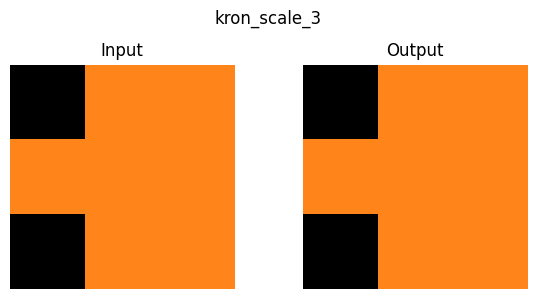

tile_repeat_3x3 False


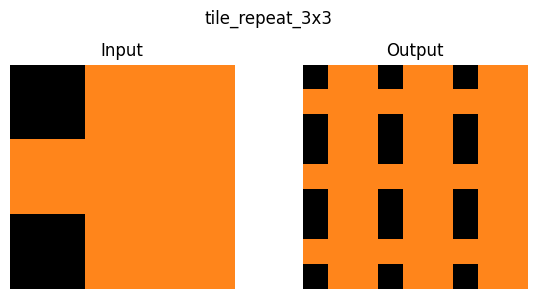

block_stamp_expand True


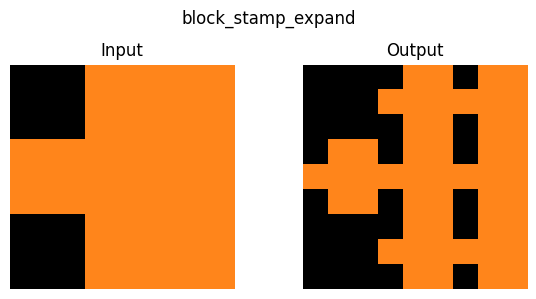

In [28]:
# =============================
# STEP 3: Test the candidate rules
# =============================
# We apply each candidate rule to the input
# and compare the result with the true output.
candidates = {
    "kron_scale_3": kron_scale(inp, 3),
    "tile_repeat_3x3": tile_repeat(inp, 3, 3),
    "block_stamp_expand": block_stamp_expand(inp),
}

for name, pred in candidates.items():
    print(name, np.array_equal(pred, out))
    show_example(inp, pred, title=name)

In [29]:
# =============================
# BLOCK-STAMP EXPANSION RULE
# =============================

# This function applies the block-stamp rule:
# Each nonzero input cell creates a full copy of the input grid
# in the corresponding block of the output.
def block_stamp_expand(grid):
    # Get input height and width
    h, w = grid.shape

    # Create output grid:
    # It will be (h*h, w*w)
    out = np.zeros((h * h, w * w), dtype=int)

    # Loop through each input cell
    for r in range(h):
        for c in range(w):

            # If the cell is not black (0)
            if grid[r, c] != 0:

                # Place full input grid into output block
                out[r*h:(r+1)*h, c*w:(c+1)*w] = grid

    return out

In [30]:
# =============================
# DETECT BLOCK-STAMP RULE
# =============================

def learn_block_stamp_rule(train_examples):

    # Check every training example
    for ex in train_examples:
        inp = np.array(ex["input"], dtype=int)
        out = np.array(ex["output"], dtype=int)

        # Apply the rule
        pred = block_stamp_expand(inp)

        # If any example fails → rule is not valid
        if not np.array_equal(pred, out):
            return None

    # If all examples match, return the solver
    def solve(grid):
        return block_stamp_expand(grid)

    return {
        "rule_name": "block_stamp_expand",
        "solve": solve,
    }

In [31]:
# =============================
# TEMP RULE LIST (SAFE)
# =============================
rule_learners = [
    learn_block_stamp_rule,   # Only rule defined so far
]

Detected rule: block_stamp_expand


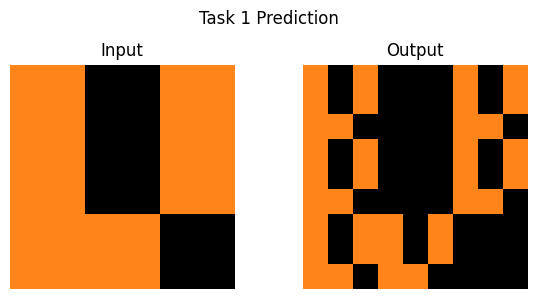

In [32]:
# Learn rule from training examples
rule = learn_block_stamp_rule(task["train"])

print("Detected rule:", rule["rule_name"])

# Apply to test input
test_input = np.array(task["test"][0]["input"], dtype=int)

pred = rule["solve"](test_input)

# Visualize
show_example(test_input, pred, title="Task 1 Prediction")

In [33]:
# =============================
# DEFINE RULE LIST (SAFE VERSION)
# =============================

# This list contains all rule detection functions.
# For now, we only include the one rule we have implemented.
rule_learners = [
    learn_block_stamp_rule,   # This is currently the ONLY defined rule
]

In [34]:
# =============================
# APPLY RULE ENGINE TO TASK 1
# =============================

# Get Task 1
name1, task1 = tasks[0]

# Try each rule in the list
rule = None

for learner in rule_learners:
    
    # Try to learn a rule from training examples
    rule = learner(task1["train"])
    
    # If a rule is found, stop
    if rule is not None:
        break

# Print detected rule
print("Detected rule:", rule["rule_name"])

Detected rule: block_stamp_expand


In [35]:
# =============================
# TASK 2: LOAD AND INSPECT
# =============================

# Select the second loaded task.
name2, task2 = tasks[1]

# Print task name.
print("Task:", name2)

# Print number of training examples.
print("Train examples:", len(task2["train"]))

# Print number of test examples.
print("Test examples:", len(task2["test"]))

Task: task002.json
Train examples: 5
Test examples: 1


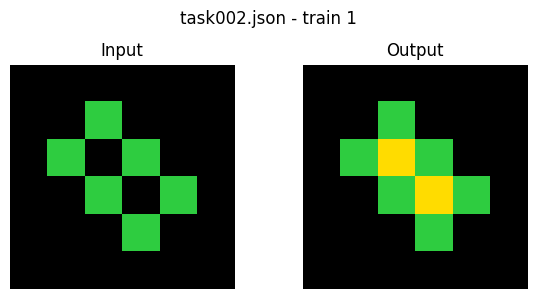

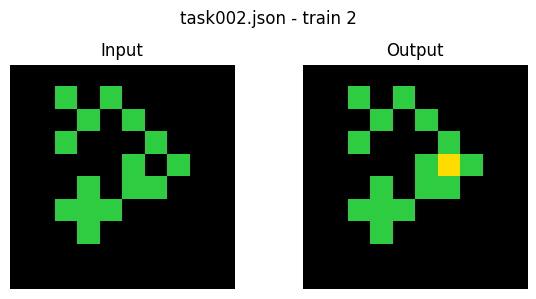

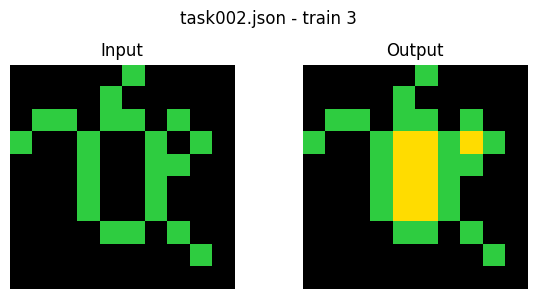

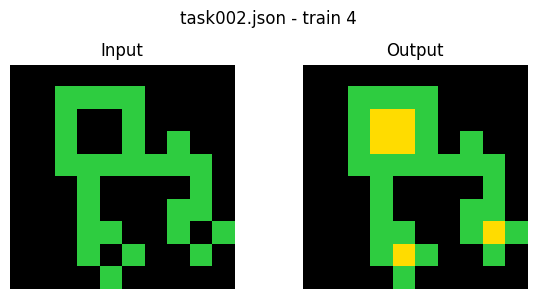

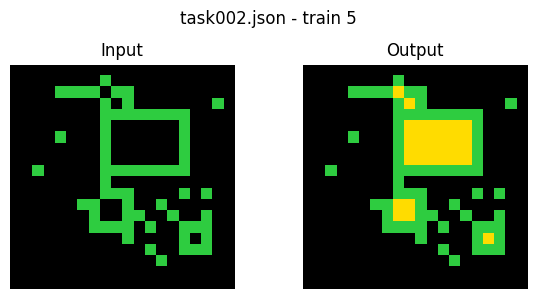

In [36]:
# =============================
# TASK 2: VISUALIZE TRAINING EXAMPLES
# =============================

# Loop through all training examples.
for i, ex in enumerate(task2["train"]):

    # Convert input grid to NumPy array.
    inp = np.array(ex["input"], dtype=int)

    # Convert output grid to NumPy array.
    out = np.array(ex["output"], dtype=int)

    # Show input and output side by side.
    show_example(inp, out, title=f"{name2} - train {i+1}")

Input:
[[0 0 0 0 0 0]
 [0 0 3 0 0 0]
 [0 3 0 3 0 0]
 [0 0 3 0 3 0]
 [0 0 0 3 0 0]
 [0 0 0 0 0 0]]

Output:
[[0 0 0 0 0 0]
 [0 0 3 0 0 0]
 [0 3 4 3 0 0]
 [0 0 3 4 3 0]
 [0 0 0 3 0 0]
 [0 0 0 0 0 0]]

Changed cells mask:
[[0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 1 0 0 0]
 [0 0 0 1 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]]


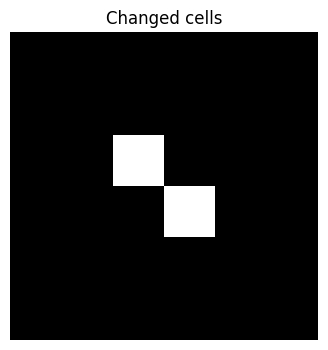

In [37]:
# =============================
# TASK 2: SHOW CHANGED CELLS
# =============================

# Select first training example.
ex = task2["train"][0]

# Convert input to NumPy array.
inp = np.array(ex["input"], dtype=int)

# Convert output to NumPy array.
out = np.array(ex["output"], dtype=int)

# Check if input and output have the same shape.
if inp.shape == out.shape:

    # Create a mask showing where cells changed.
    changed = (inp != out).astype(int)

    # Print input grid.
    print("Input:")
    print(inp)

    # Print output grid.
    print("\nOutput:")
    print(out)

    # Print changed-cell mask.
    print("\nChanged cells mask:")
    print(changed)

    # Display changed cells visually.
    plt.figure(figsize=(4, 4))
    plt.imshow(changed, cmap="gray")
    plt.title("Changed cells")
    plt.axis("off")
    plt.show()

else:
    # If shapes differ, changed-cell comparison is not valid.
    print("Input and output shapes differ.")
    print("Input shape :", inp.shape)# =============================
# TASK 2 RULE: INTERIOR FILL
# =============================

def fill_interior(grid):
    # Get grid size
    h, w = grid.shape

    # Create a copy so we don’t modify the original grid
    out = grid.copy()

    # Loop through each cell
    for r in range(h):
        for c in range(w):

            # Only consider cells that are color 3
            if grid[r, c] != 3:
                continue

            # Assume this cell is interior
            is_interior = True

            # Check 4-directional neighbors (up, down, left, right)
            for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                
                rr, cc = r + dr, c + dc

                # If neighbor is out of bounds OR not 3 → this is boundary
                if rr < 0 or rr >= h or cc < 0 or cc >= w or grid[rr, cc] != 3:
                    is_interior = False
                    break

            # If cell is interior, change it to 4
            if is_interior:
                out[r, c] = 4

    return out

In [38]:
# =============================
# TASK 2 RULE: INTERIOR FILL
# =============================

def fill_interior(grid):
    # Get grid size
    h, w = grid.shape

    # Create a copy so we don’t modify the original grid
    out = grid.copy()

    # Loop through each cell
    for r in range(h):
        for c in range(w):

            # Only consider cells that are color 3
            if grid[r, c] != 3:
                continue

            # Assume this cell is interior
            is_interior = True

            # Check 4-directional neighbors (up, down, left, right)
            for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                
                rr, cc = r + dr, c + dc

                # If neighbor is out of bounds OR not 3 → this is boundary
                if rr < 0 or rr >= h or cc < 0 or cc >= w or grid[rr, cc] != 3:
                    is_interior = False
                    break

            # If cell is interior, change it to 4
            if is_interior:
                out[r, c] = 4

    return out

In [39]:
# Test on all training examples
all_match = True

for i, ex in enumerate(task2["train"]):
    inp = np.array(ex["input"], dtype=int)
    out = np.array(ex["output"], dtype=int)

    pred = fill_interior(inp)

    match = np.array_equal(pred, out)
    print(f"Train {i+1}: {match}")

    if not match:
        all_match = False

print("\nRule works on all examples:", all_match)

Train 1: False
Train 2: False
Train 3: False
Train 4: False
Train 5: False

Rule works on all examples: False


In [40]:
# =============================
# TASK 2 RULE TEST: 2x2 GREEN BLOCK CORNER
# =============================

# This function looks for every 2x2 block made entirely of color 3.
# When it finds one, it changes the lower-right cell of that block to color 4.
def mark_2x2_green_blocks(grid):

    # Copy the original grid so we keep all existing cells unchanged.
    out = grid.copy()

    # Get the height and width of the grid.
    h, w = grid.shape

    # Loop over all possible top-left corners of a 2x2 block.
    for r in range(h - 1):

        # Loop over all possible top-left columns of a 2x2 block.
        for c in range(w - 1):

            # Extract the current 2x2 block.
            block = grid[r:r+2, c:c+2]

            # Check whether all four cells in this 2x2 block are color 3.
            if np.all(block == 3):

                # Mark the lower-right cell of the 2x2 block as color 4.
                out[r+1, c+1] = 4

    # Return the transformed grid.
    return out

In [41]:
# =============================
# TEST 2x2 BLOCK RULE ON ALL TASK 2 TRAINING EXAMPLES
# =============================

# Assume the rule works until one example fails.
all_match = True

# Loop through all Task 2 training examples.
for i, ex in enumerate(task2["train"]):

    # Convert input grid to NumPy array.
    inp = np.array(ex["input"], dtype=int)

    # Convert expected output grid to NumPy array.
    out = np.array(ex["output"], dtype=int)

    # Apply the candidate rule.
    pred = mark_2x2_green_blocks(inp)

    # Check exact match.
    match = np.array_equal(pred, out)

    # Print result for this example.
    print(f"Train {i+1}: {match}")

    # If one example fails, record that the rule is not perfect.
    if not match:
        all_match = False

# Print final result.
print("\nRule works on all examples:", all_match)

Train 1: False
Train 2: False
Train 3: False
Train 4: False
Train 5: False

Rule works on all examples: False


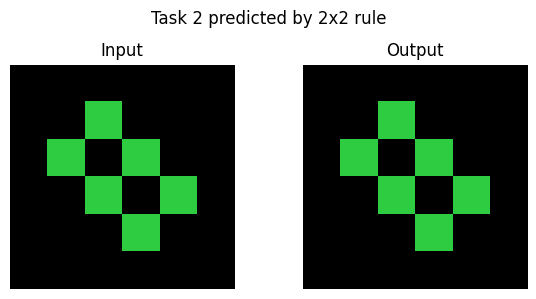

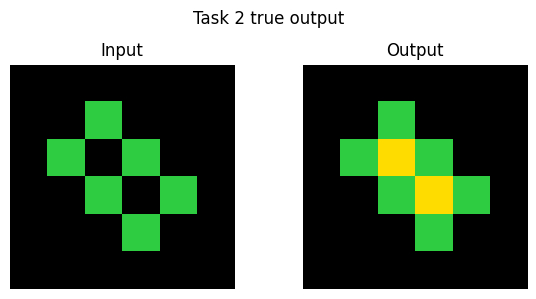

Prediction:
[[0 0 0 0 0 0]
 [0 0 3 0 0 0]
 [0 3 0 3 0 0]
 [0 0 3 0 3 0]
 [0 0 0 3 0 0]
 [0 0 0 0 0 0]]

True output:
[[0 0 0 0 0 0]
 [0 0 3 0 0 0]
 [0 3 4 3 0 0]
 [0 0 3 4 3 0]
 [0 0 0 3 0 0]
 [0 0 0 0 0 0]]

Difference mask:
[[0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 1 0 0 0]
 [0 0 0 1 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]]


In [42]:
# =============================
# VISUALIZE TASK 2 PREDICTION VS TRUE OUTPUT
# =============================

# Select first training example.
ex = task2["train"][0]

# Convert input to array.
inp = np.array(ex["input"], dtype=int)

# Convert true output to array.
true_out = np.array(ex["output"], dtype=int)

# Apply candidate rule.
pred_out = mark_2x2_green_blocks(inp)

# Show input and prediction.
show_example(inp, pred_out, title="Task 2 predicted by 2x2 rule")

# Show input and true output.
show_example(inp, true_out, title="Task 2 true output")

# Print arrays for comparison.
print("Prediction:")
print(pred_out)

print("\nTrue output:")
print(true_out)

print("\nDifference mask:")
print((pred_out != true_out).astype(int))

In [43]:
# =============================
# TASK 2 RULE: CORE / CENTRAL CELLS
# =============================

def mark_core_cells(grid):

    # Get grid size
    h, w = grid.shape

    # Copy grid so we preserve original values
    out = grid.copy()

    # Loop through all cells
    for r in range(h):
        for c in range(w):

            # Only consider green cells (color 3)
            if grid[r, c] != 3:
                continue

            # Count how many neighbors are also green
            neighbor_count = 0

            # Check 4-directional neighbors
            for dr, dc in [(-1,0),(1,0),(0,-1),(0,1)]:
                rr, cc = r + dr, c + dc

                # Check bounds and color
                if 0 <= rr < h and 0 <= cc < w:
                    if grid[rr, cc] == 3:
                        neighbor_count += 1

            # If this cell is well-connected (core of shape)
            if neighbor_count >= 2:
                out[r, c] = 4   # mark as yellow

    return out

In [44]:
# =============================
# TEST CORE RULE
# =============================

all_match = True

for i, ex in enumerate(task2["train"]):

    inp = np.array(ex["input"], dtype=int)
    out = np.array(ex["output"], dtype=int)

    pred = mark_core_cells(inp)

    match = np.array_equal(pred, out)
    print(f"Train {i+1}: {match}")

    if not match:
        all_match = False

print("\nRule works on all examples:", all_match)

Train 1: False
Train 2: False
Train 3: False
Train 4: False
Train 5: False

Rule works on all examples: False
